# What Are Transformers?
* Developed to solve the problem of **sequence transduction, or neural machine translation**
* Which means they are meant to **solve any task that transforms an input sequence to an output sequence.**

###*A transformer is a type of artificial intelligence model that learns to understand and generate human-like text by analyzing patterns in large amounts of text data.*

Encoder-decoder architecture **relies mainly on Recurrent Neural Networks (RNNs)** to extract sequential information, **Transformers completely lack this recurrency**.

Comprehend context and meaning by analyzing the relationship between different elements, and they ***rely almost entirely on a mathematical technique called attention to do so***.

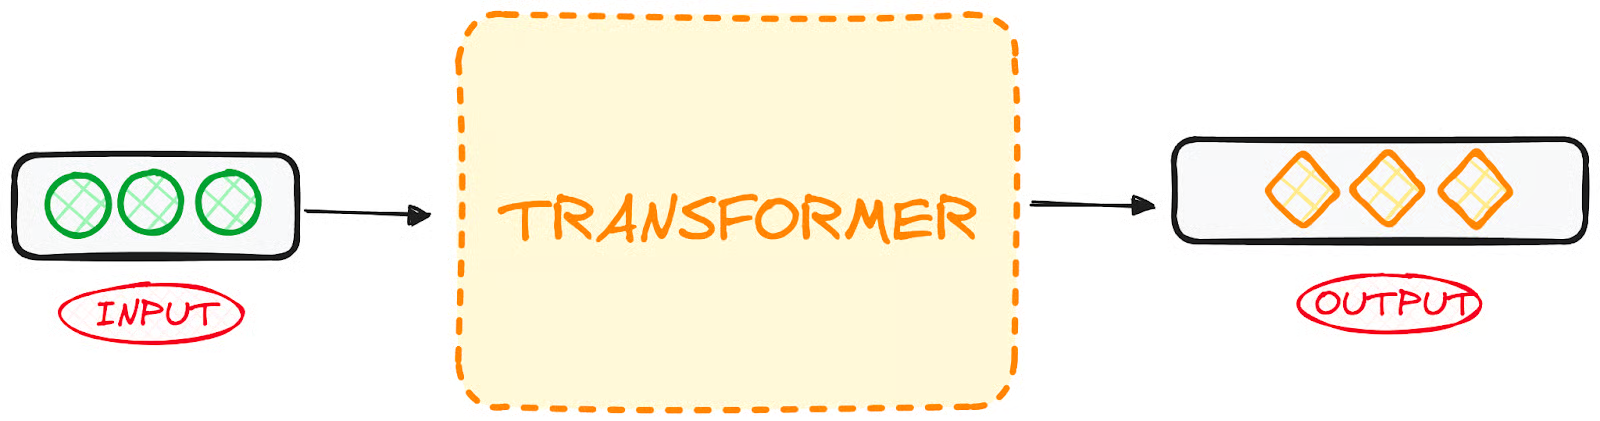

[Attention Is All You Need](https://arxiv.org/pdf/1706.03762)

# **Encoder-Decoder Architecture**
* Sequence to sequence architecture
* Consumes sequence and spits out sequence
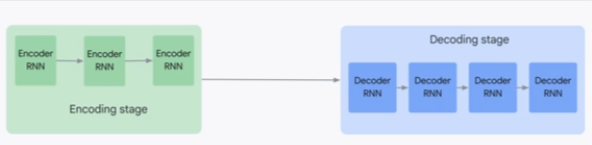

### **Encoder Stage**
1. Takes the input data like a sentence
2. Processes each word one by one
3. Then creates a single, fixed-size summary of the entire input called a ***context vector or latent space***.
### **Decoder Stage**
1. Takes the context vector and begins to produce the output one step at a time.

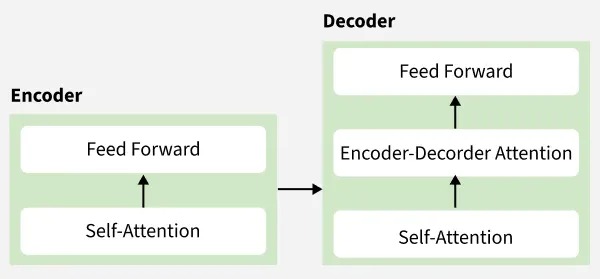

***Encoder***: The encoder's job is to process the ***input data and convert it into a form that the model can understand***.
1. ***Self-Attention Layer:***  
  * Focus on **different parts of the input data** that are important for **understanding the context**.
  * For example in a sentence it allows the model to **consider how each word relates to the others**.

2. ***Feed-Forward Neural Network:***

  * After the self-attention layer this network **processes the information further to capture complex patterns and relationships** in the data.

***Decoder:***
1. **Self-Attention Layer**: Similar to the encoder this layer **allows the decoder to focus on different parts of the output it has generated**.

2. **Encoder-Decoder Attention Layer**: This unique layer enables the decoder to focus on **relevant parts of the input data help to generate more accurate outputs**.

3. **Feed-Forward Neural Network:** Like the encoder the decoder uses this network to process the information and generate the final output.

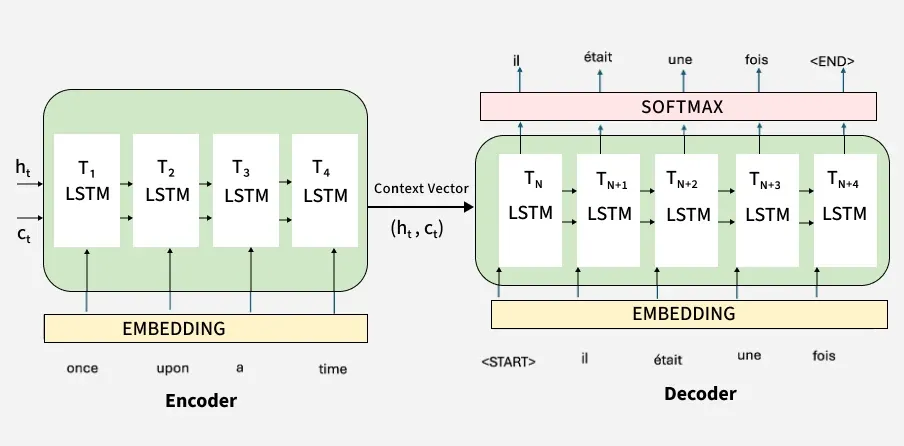

# Step 1: Tokenizing the Input Sentence
* The sentence "I am learning AI" is first broken into tokens: ["I", "am", "learning", "AI"].
* Each word (token) is **converted into a vector** that a machine can understand. ***This process is called embedding.***

# Step 2: Encoding the Input
* Encoder processes these embeddings using self-attention.
* Focus on important words
* For example while encoding ***"learning", it understands its relation with "I" and "AI."***
* encoder generates a ***Context Vector*** which captures the ***meaning of the entire sentence***
* The final output from the encoder is the ***context representation***

# Step 3: Passing the Context to the Decoder
* It acts like a summary of the full input sentence.


# Step 4: Decoder Generates Output Step-by-Step

* Decoder ***uses the context and starts creating the output one word at a time***.
* First it predicts the first word then uses that to predict the second word and so on.

# Step 5: Decoder Attention
* Decoder ***attends to different parts of the input sentence to make better predictions***.
* For example when translating "learning," it might **pay more attention to the word "learning" in the input**.

# Step 6: Producing the Final Output
* Each ***output token depends on the previous ones and the input context***.

########################

# 🧠 Real-World Example: Neural Machine Translation
## Task: English → French translation using Encoder–Decoder with Attention

In [ ]:
# ------------------------------------------------------------
# ENCODER-DECODER WITH ATTENTION (English → French Translation)
# ------------------------------------------------------------
#sequence-to-sequence (Seq2Seq) model with attention
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dot, Activation, Concatenate

In [ ]:
#Demonstration how the Tokenizer class in Keras works
# Step 1: Sample corpus (text data)
sentences = [
    "I love deep learning",
    "Deep learning loves me",
    "I love NLP and deep learning"
]
# Step 2: Initialize Tokenizer
tokenizer = Tokenizer(num_words=10, oov_token="<OOV>")
# num_words limits the vocabulary size
# oov_token handles words not seen during training

# Step 3: Fit the Tokenizer on the text data
tokenizer.fit_on_texts(sentences)

# Step 4: Display the word-to-index dictionary
word_index = tokenizer.word_index
print("Word Index (word → integer):")
print(word_index)

# Step 5: Convert sentences to sequences (numerical form)
sequences = tokenizer.texts_to_sequences(sentences)
print("\nSequences (text → integers):")
print(sequences)

Word Index (word → integer):
{'<OOV>': 1, 'deep': 2, 'learning': 3, 'i': 4, 'love': 5, 'loves': 6, 'me': 7, 'nlp': 8, 'and': 9}

Sequences (text → integers):
[[4, 5, 2, 3], [2, 3, 6, 7], [4, 5, 8, 9, 2, 3]]


In [ ]:
#Demonstration how the Padding in Keras works
# Step 1: Sample text corpus
sentences = [
    "I love deep learning",
    "Deep learning loves me",
    "I love NLP and deep learning"
]

# Step 2: Initialize and fit the tokenizer
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(sentences)

# Step 3: Convert text to sequences (numerical form)
sequences = tokenizer.texts_to_sequences(sentences)
print("Original Sequences:")
print(sequences)

# Step 4: Pad the sequences to make them the same length
padded = pad_sequences(sequences, padding='post')  # or 'pre'
print("\nPadded Sequences:")
print(padded)

Original Sequences:
[[4, 5, 2, 3], [2, 3, 6, 7], [4, 5, 8, 9, 2, 3]]

Padded Sequences:
[[4 5 2 3 0 0]
 [2 3 6 7 0 0]
 [4 5 8 9 2 3]]


### 🏗️ Keras Layers Breakdown
These imported layers form the building blocks of the neural network:
| Layer Name | Role in the Model |
| :--- | :--- |
| **`Input`** | Defines the **entry point** of a tensor into the model. Separate `Input` layers are used for the **encoder** and **decoder** sequences. |
| **`LSTM`** | **Long Short-Term Memory** layer. This RNN is designed to handle **long-term dependencies**. One LSTM acts as the **Encoder** (reads input) and another as the **Decoder** (generates output). |
| **`Dense`** | A standard **fully-connected layer**. Used for transforming vector spaces and typically as the **final layer** for classification (e.g., predicting the next word). |
| **`Embedding`** | The **first hidden layer** for text data. It maps integer-encoded words to dense **word embedding vectors**, which represent the word's meaning. |
| **`Dot`** | Performs a **dot product**. In the attention mechanism, it calculates **"alignment scores"** or **"attention weights"** between the encoder's outputs and the decoder's current state. |
| **`Activation`** | Applies an **activation function** (e.g., `softmax` to normalize weights or `relu`). |
| **`Concatenate`** | Joins a list of tensors. In attention, it **combines** the **context vector** (weighted encoder output) with the **decoder's output** before the final prediction. |

In [ ]:
# -------------------------------
# 1. Prepare Sample Training Data
# -------------------------------
# For classroom demo, small sample (you can replace with dataset like fra-eng.txt)
english_sentences = ["i love apples", "you like bananas", "she eats bread"]
french_sentences = ["j aime les pommes", "tu aimes les bananes", "elle mange du pain"]

In [ ]:
# Tokenize source (English)
src_tokenizer = Tokenizer()
src_tokenizer.fit_on_texts(english_sentences)
src_sequences = src_tokenizer.texts_to_sequences(english_sentences)
src_word_index = src_tokenizer.word_index
src_vocab_size = len(src_word_index) + 1

In [ ]:
src_word_index

{'i': 1,
 'love': 2,
 'apples': 3,
 'you': 4,
 'like': 5,
 'bananas': 6,
 'she': 7,
 'eats': 8,
 'bread': 9}

In [ ]:
src_vocab_size

10

In [ ]:
# Tokenize target (French)
tgt_tokenizer = Tokenizer()
tgt_tokenizer.fit_on_texts(french_sentences)
tgt_sequences = tgt_tokenizer.texts_to_sequences(french_sentences)
tgt_word_index = tgt_tokenizer.word_index
tgt_vocab_size = len(tgt_word_index) + 1

In [ ]:
src_sequences

[[1, 2, 3], [4, 5, 6], [7, 8, 9]]

In [ ]:
tgt_sequences

[[2, 3, 1, 4], [5, 6, 1, 7], [8, 9, 10, 11]]

In [ ]:
max_src_len = max(len(s) for s in src_sequences)
max_tgt_len = max(len(s) for s in tgt_sequences)

In [ ]:
max_src_len

3

In [ ]:
max_tgt_len

4

In [ ]:
src_padded = pad_sequences(src_sequences, maxlen=max_src_len, padding='post')
tgt_padded = pad_sequences(tgt_sequences, maxlen=max_tgt_len, padding='post')

In [ ]:
# ---------------------------------
# 2. Build Encoder-Decoder with Attention
# ---------------------------------
embed_dim = 32 #dimensionality of the word embedding vectors.
units = 64  #sets the number of units or hidden state dimensions within the Recurrent Neural Network (RNN) layers.

In [ ]:
# Encoder
encoder_inputs = Input(shape=(max_src_len,))
enc_emb = Embedding(src_vocab_size, embed_dim)(encoder_inputs)
encoder_lstm = LSTM(units, return_sequences=True, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)

### encoder_lstm = LSTM(units, return_sequences=True, return_state=True)
* Action: Defines the LSTM layer responsible for reading the entire source sequence and compressing its information.
* Layer: LSTM layer.
* units: Sets the size of the hidden state and cell state (e.g., 64). This is the "memory" capacity of the LSTM.
* return_sequences=True: Crucial for Attention. This setting ensures that the LSTM outputs a hidden state for every time step (every word). These outputs are necessary for the Attention Mechanism to calculate alignment scores with the decoder.
* return_state=True: Ensures that the final internal hidden state ($\mathbf{h}$) and cell state ($\mathbf{c}$) of the LSTM are returned. These final states capture the overall "context" of the input sentence.

### encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)
* Action: Executes the LSTM calculation on the embedded input and captures the results.
encoder_outputs: The sequence of hidden states generated at every time step (due to return_sequences=True). These are the values used by the attention mechanism.

* state_h (Hidden State): The final hidden state of the LSTM. This is often used as the initial hidden state for the decoder.

* state_c (Cell State): The final cell state of the LSTM. This is often used as the initial cell state for the decoder.

* encoder_lstm(enc_emb): Connects the defined encoder_lstm layer to the embedded input tensor.

In [ ]:
# Decoder
decoder_inputs = Input(shape=(max_tgt_len,))
dec_emb = Embedding(tgt_vocab_size, embed_dim)(decoder_inputs)
decoder_lstm = LSTM(units, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=[state_h, state_c])

### decoder_inputs = Input(shape=(max_tgt_len,))
* Action: Defines the entry point for the target language sequences (e.g., French).

* Layer: Input layer.

* shape=(max_tgt_len,): Specifies the expected shape of the input, which is a sequence of integer tokens padded to the length of the longest target sentence.

* Purpose: These inputs are the "***teacher-forced***" sequences—the ground truth target sentences, but shifted by one time step (e.g., starting with a <START> token) to train the decoder to predict the next word.

* return_sequences=True: Crucial. This ensures the LSTM outputs a hidden state for every time step. These sequences are needed for two things:

  1. The final Dense layer will use these to predict the next word in the sequence.

  2. The Attention Mechanism will use these (in advanced models) to compute alignment scores.

* return_state=True: While the decoder LSTM returns its final states, they are typically not used during training (as they're overwritten by the encoder's states), which is why they are often ignored in the next line.

### decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=[state_h, state_c])
* Action: Executes the decoder LSTM, generating the output sequence.
* dec_emb: The embedded target input.
* initial_state=[state_h, state_c]:  Crucial Connection. This is where the encoder's final context (state_h and state_c from the encoder LSTM) is passed to the decoder. This transfers the meaning or summary of the source sentence, giving the decoder a starting point for generation.
* decoder_outputs: The sequence of hidden states generated by the decoder at every time step.
* _, _: The final hidden and cell states of the decoder LSTM are captured but typically discarded (represented by the underscore _) because their primary use is during the inference/prediction phase, not the training phase

# 👩‍🏫 Training: Teacher Forcing
Teacher Forcing is a method used only during the training phase of Seq2Seq models.
### How It Works
1. Input: The decoder is given the correct target sequence (the ***ground truth translation***), but shifted one position to the right (***prepended with a START token***).

2. Forced Input: ***Instead of using the word it just predicted as the input for the next time step***, the decoder is ***forced to use the correct next word from the ground truth sequence***.

### Example (Translating "I am happy" to "Je suis content"):

* Decoder Input Sequence (Teacher): [<START>, Je, suis, content, <END>]

* Time Step 1: Input is START. Decoder predicts Je.

* Time Step 2: Input is forced to be the correct word, Je. Decoder predicts suis.

* Time Step 3: Input is forced to be the correct word, suis. Decoder predicts content.

### Why It's Used
  1. ***Faster Convergence***: It stabilizes training and allows the model to learn faster because it's always seeing the correct context.

  2. ***Avoids Error Accumulation*** : If the decoder **makes a mistake early in the sequence (e.g., predicts "Nous" instead of "Je")**, the model is not forced to continue translating based on that error. It immediately resets and continues learning from the correct context.



**Connection to Your Code**

The line decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=[state_h, state_c]) **uses Teacher Forcing. The dec_emb (the embedded decoder_inputs) contains the entire, correct, padded target sequence, meaning the decoder is processing all target words simultaneously during training**.

In [ ]:
# Attention Layer (Bahdanau style)
attention = Dot(axes=[2, 2])([decoder_outputs, encoder_outputs])
#calculates the raw alignment score (or energy) between every output hidden state of the decoder and every output hidden state of the encoder. It determines how well each decoder step aligns with each encoder word.

attention = Activation('softmax')(attention)
#Converts the raw alignment scores into a probability distribution, called the Attention Weights

#creates the Context Vector
context = Dot(axes=[2,1])([attention, encoder_outputs])

decoder_combined_context = Concatenate(axis=-1)([context, decoder_outputs])
output = Dense(tgt_vocab_size, activation='softmax')(decoder_combined_context)

model = Model([encoder_inputs, decoder_inputs], output)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 3, 32)     │        320 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 4, 32)     │        384 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 3, 64),   │     24,832 │ embedding[0][0]   │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 4, 64),   │     24,832 │ embedding_1[0][0… │
│                     │ (None, 64),       │            │ lstm[0][1],       │
│                     │ (None, 64)]       │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 4, 3)      │          0 │ lstm_1[0][0],     │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 4, 3)      │          0 │ dot[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_1 (Dot)         │ (None, 4, 64)     │          0 │ activation[0][0], │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 4, 128)    │          0 │ dot_1[0][0],      │
│ (Concatenate)       │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4, 12)     │      1,548 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 51,916 (202.80 KB)

 Trainable params: 51,916 (202.80 KB)

 Non-trainable params: 0 (0.00 B)

* Categorical Cross-Entropy: This is the correct loss function for a multi-class classification problem (predicting one word out of a vocabulary).

* Sparse: This is used when the true target labels are provided as integers (the token IDs), which is the case when you use pad_sequences on your target sequences. If you were to use one-hot encoded labels, you would use 'categorical_crossentropy'.

In [ ]:
# ---------------------------------
# 3. Training (for demo, just 100 epochs)
# ---------------------------------
import numpy as np
model.fit([src_padded, tgt_padded], np.expand_dims(tgt_padded, -1),
          batch_size=1, epochs=100, verbose=0)

In [ ]:
# ---------------------------------
# 4. Simple Inference Demo
# ---------------------------------
def translate(sentence):
    seq = src_tokenizer.texts_to_sequences([sentence])
    seq = pad_sequences(seq, maxlen=max_src_len, padding='post')
    output = model.predict([seq, np.zeros((1, max_tgt_len))])
    out_seq = np.argmax(output[0], axis=-1)
    #Inverse Mapping dictionary:-inverts it to map integer ID $\rightarrow$ word. This is essential for converting the predicted IDs back into human-readable text.
    inv_map = {v: k for k, v in tgt_word_index.items()}
    words = [inv_map.get(i, '') for i in out_seq if i > 0]
    return " ".join(words)

print("\n🔹 Translation Demo:")
print("English: i love apples → French:", translate("i love apples"))


🔹 Translation Demo:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
English: i love apples → French: j aime les pommes


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step
Attention shape: (1, 4, 3)


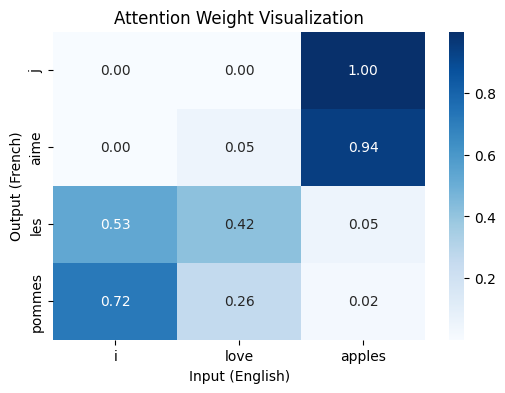

In [ ]:
# ------------------------------------------------------------
# BUILD AN ATTENTION MODEL FOR VISUALIZATION
# ------------------------------------------------------------
# Create a model that outputs attention weights given inputs
attention_extractor = Model(inputs=[encoder_inputs, decoder_inputs], outputs=attention)

# Use your existing padded data for one example
sample_src = src_padded[0:1]
sample_tgt = tgt_padded[0:1]

# Run inference to get actual attention weights
attn_weights = attention_extractor.predict([sample_src, sample_tgt])

print("Attention shape:", attn_weights.shape)  # (batch, tgt_len, src_len)

# ------------------------------------------------------------
# VISUALIZE ATTENTION WEIGHTS
# ------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Choose first example, squeeze batch dimension
attn_matrix = np.squeeze(attn_weights, axis=0)

# Get tokens
input_tokens = english_sentences[0].split()
output_tokens = french_sentences[0].split()

plt.figure(figsize=(6,4))
sns.heatmap(attn_matrix[:len(output_tokens), :len(input_tokens)],
            xticklabels=input_tokens, yticklabels=output_tokens,
            cmap='Blues', annot=True, fmt=".2f")

plt.xlabel("Input (English)")
plt.ylabel("Output (French)")
plt.title("Attention Weight Visualization")
plt.show()


## 🤖 Inference (Prediction) Strategies

### A. Greedy Search (Simple & Fast)

* **Concept:** At each time step, the decoder simply selects the word with the **highest probability** right now.
* **Process:**
    1.  Predict the first word.
    2.  Select the word with the max probability.
    3.  Use this selected word as the input for the next time step.
    4.  Repeat until `<END>` token is predicted or max length is reached.
* **Drawback:** It's **suboptimal**. It makes locally optimal choices that might lead to a poor global sequence. For instance, an early word with probability $0.8$ might lock out a later, much better sequence (e.g., probability $0.9 + 0.9 = 0.81$) in favor of an inferior global sequence (e.g., probability $0.8 + 0.6 = 0.48$).

---

### B. Beam Search (Better Quality)

* **Concept:** **Beam Search** keeps track of the **top $k$ most likely partial sequences** (the "beam") at each time step, instead of just the single best one. This helps find a globally better sequence.
* **Hyperparameter:** The **Beam Width ($k$)** is the number of hypotheses kept. Common values are 3 to 10.
* **Process:**
    1.  **Time Step 1:** Predict the first word. Select the top $k$ words (e.g., $k=5$). You now have $k$ partial sequences of length 1.
    2.  **Time Step 2:** Extend all $k$ sequences by trying every possible next word. You now have $k \times \text{Vocab Size}$ new sequences.
    3.  Evaluate the **cumulative probability** (log-likelihood) of all these new sequences.
    4.  Prune the list back down to the **top $k$ best sequences**.
    5.  Repeat until all $k$ sequences terminate with `<END>` or hit max length.
* **Advantage:** It is far more likely to find a high-quality translation than Greedy Search because it explores multiple paths simultaneously.
* **Drawback:** It is significantly **slower** and more computationally expensive than Greedy Search.

####################################

# Attention in NLP
* The goal of self attention mechanism is to **improve performance of traditional models such as encoder decoder models used in RNNs (Recurrent Neural Networks)**.
* In traditional encoder decoder models **input sequence is compressed into a single fixed-length vector which is then used to generate the output**.
* This works **well for short sequences but struggles with long ones** because **important information can be lost when compressed into a single vector**.
* To overcome this problem self attention mechanism was introduced.

# Word Embeddings in NLP
* Numeric representations of words in a **lower-dimensional space**, that **capture semantic and syntactic information**.
* Method of **extracting features out of text** so that we can input those features into a **machine learning model to work with text data**.
* It allows words with similar meanings to have a similar representation. Thus, Similarity can be assessed based on Similar vector representations.

### Words ----> Numeric representation ----> Use in Training or Inference.
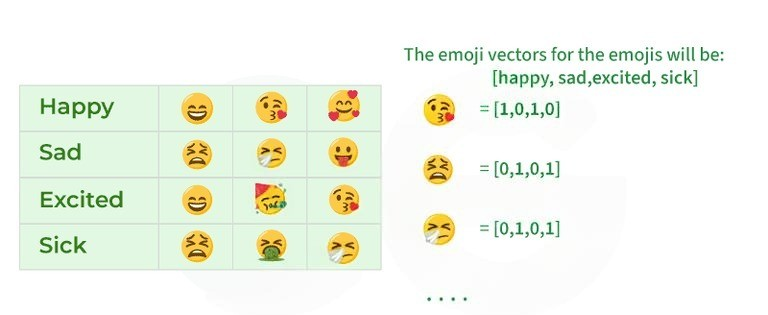


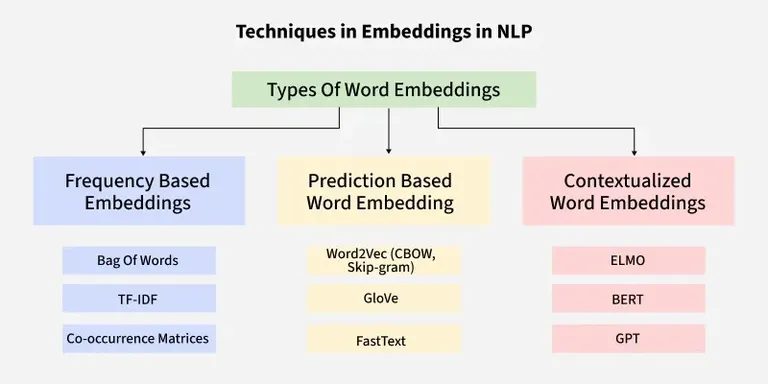

# One-Hot Encoding
* Method for converting categorical variables into a binary format.
* It creates new columns for each category where 1 means the category is present and 0 means it is not.

## 🛍️ What are Categorical Variables?
A categorical variable a**ssigns observations to discrete categories**. Since most machine learning algorithms work best with numerical input, these variables need to be transformed.

### 1. Nominal Categorical Variables
* These are categories that **exist without any intrinsic rank or order**.

* Examples:

  * Color: Red, Green, Blue

  * City: New York, London, Tokyo

  * Gender: Male, Female, Non-binary



### 2. Ordinal Categorical Variables
* These are categories that **have a clear, meaningful order or hierarchy**, but the difference between categories may not be uniform.
* Examples:

  * Satisfaction: Very Unsatisfied, Unsatisfied, Neutral, Satisfied, Very Satisfied

  * Education Level: High School, Bachelor's, Master's, PhD

  * T-Shirt Size: Small, Medium, Large

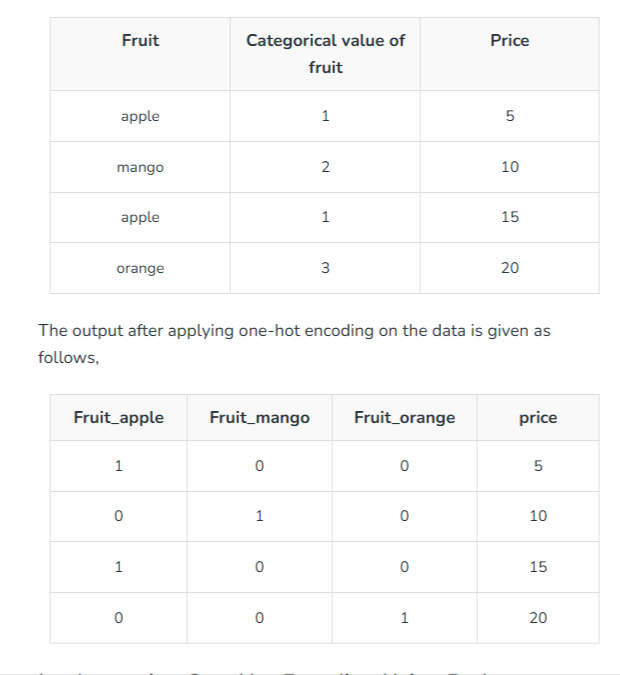

# Implementing One-Hot Encoding Using Python
Using Pandas:- offers the get_dummies function


In [ ]:
import pandas as pd
import numpy as np # Imported to show the original code used it implicitly

data = {
    'Employee id': [10, 20, 15, 25, 30],
    'Gender': ['M', 'F', 'F', 'M', 'F'],
    'Remarks': ['Good', 'Nice', 'Good', 'Great', 'Nice']
}

df = pd.DataFrame(data)
print(f"Original Employee Data:\n{df}\n")

# --- SIMPLIFIED ONE-HOT ENCODING ---
# The pandas get_dummies method is the easiest way to do this.
# columns specifies which columns to transform.
# drop_first=True prevents multicollinearity by dropping one category per feature.
df_encoded = pd.get_dummies(df, columns=['Gender', 'Remarks'], drop_first=True)

print(f"One-Hot Encoded Data (Simplified Pandas Method):\n{df_encoded}\n")

Original Employee Data:
   Employee id Gender Remarks
0           10      M    Good
1           20      F    Nice
2           15      F    Good
3           25      M   Great
4           30      F    Nice

One-Hot Encoded Data (Simplified Pandas Method):
   Employee id  Gender_M  Remarks_Great  Remarks_Nice
0           10      True          False         False
1           20     False          False          True
2           15     False          False         False
3           25      True           True         False
4           30     False          False          True



# Alternatives to One Hot Encoding
1. Label Encoding
2. Binary Encoding
3. Target Encoding


#Bag of words (BoW) model in NLP
* It **turns** text like sentence, paragraph or document **into a collection of words**
* **Counts how often each word appears** but ignoring the order of the words.
* It does not consider the **order of the words or their grammar** but focuses on counting how often each word appears in the text.

# Steps to Implement the Bag of Words (BoW) Model

### Step 1: Preprocessing the Text
* Converting the text to lowercase
* Removing non-word characters
* Removing extra spaces

In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import nltk
import re

text = """Beans.
I was trying to explain to somebody as we were flying in, that's corn.
That's beans.
And they were very impressed at my agricultural knowledge. Please give it up for Amaury once again for that outstanding introduction. I have a bunch of good friends here today, including somebody who I served with, who is one of the finest senators in the country, and we're lucky to have him, your Senator, Dick Durbin is here. I also noticed, by the way, former Governor Edgar here, who I haven't seen in a long time, and somehow he has not aged and I have. And it's great to see you, Governor. I want to thank President Killeen and everybody at the U of I System for making it possible for me to be here today. And I am deeply honored at the Paul Douglas Award that is being given to me. He is somebody who set the path for so much outstanding public service here in Illinois. Now, I want to start by addressing the elephant in the room. I know people are still wondering why I didn't speak at the commencement."""

# 1. Tokenization
dataset = nltk.sent_tokenize(text)

# 2. Cleaning and Normalization using a list comprehension
# This single loop handles lowercasing, punctuation removal, and space normalization.
processed_dataset = []
for sentence in dataset:
    # Lowercase the sentence
    cleaned_sentence = sentence.lower()

    # Replace all non-word characters (including punctuation) with a single space
    cleaned_sentence = re.sub(r'\W', ' ', cleaned_sentence)

    # Replace multiple spaces with a single space (and trim leading/trailing spaces)
    cleaned_sentence = re.sub(r'\s+', ' ', cleaned_sentence).strip()

    # Only add non-empty sentences
    if cleaned_sentence:
        processed_dataset.append(cleaned_sentence)

# 3. Printing the results
for i, sentence in enumerate(processed_dataset):
    print(f"Sentence {i+1}: {sentence}")

Sentence 1: beans
Sentence 2: i was trying to explain to somebody as we were flying in that s corn
Sentence 3: that s beans
Sentence 4: and they were very impressed at my agricultural knowledge
Sentence 5: please give it up for amaury once again for that outstanding introduction
Sentence 6: i have a bunch of good friends here today including somebody who i served with who is one of the finest senators in the country and we re lucky to have him your senator dick durbin is here
Sentence 7: i also noticed by the way former governor edgar here who i haven t seen in a long time and somehow he has not aged and i have
Sentence 8: and it s great to see you governor
Sentence 9: i want to thank president killeen and everybody at the u of i system for making it possible for me to be here today
Sentence 10: and i am deeply honored at the paul douglas award that is being given to me
Sentence 11: he is somebody who set the path for so much outstanding public service here in illinois
Sentence 12: now

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
import nltk
from nltk.corpus import stopwords
from collections import Counter
import pandas as pd

# Ensure NLTK resources are downloaded (if you haven't already)
# nltk.download('punkt')
# nltk.download('stopwords')

# Assume 'dataset' is a list of clean, lowercased, and tokenized sentences (strings)
# Example dataset for demonstration:
# dataset = ["this is a sample sentence", "sample sentences are cool", "this is cool"]

# --- 1. Tokenize All Words and Flatten ---
# Tokenize all sentences and flatten the list of lists into a single list of all words.
all_words = []
for sentence in dataset:
    all_words.extend(nltk.word_tokenize(sentence))

# --- 2. Filter Stop Words ---
stop_words = set(stopwords.words('english'))
filtered_words = [word for word in all_words if word not in stop_words]

# --- 3. Efficiently Count Frequencies ---
# Use collections.Counter for a single-line, highly optimized count
word_counts = Counter(filtered_words)

# --- 4. Create and Sort DataFrame ---
word_freq_df = pd.DataFrame(word_counts.items(), columns=['Word', 'Frequency'])

# Sort the DataFrame by frequency in descending order
word_freq_df = word_freq_df.sort_values(by='Frequency', ascending=False).reset_index(drop=True)

print(word_freq_df)

            Word  Frequency
0              .         13
1              I         12
2              ,         12
3             's          3
4       somebody          3
..           ...        ...
78        people          1
79         still          1
80     wondering          1
81         speak          1
82  commencement          1

[83 rows x 2 columns]


Top 10 frequent words: ['.', 'I', ',', 'the', 'to', 'in', 'for', 'here', 'at', 'have']


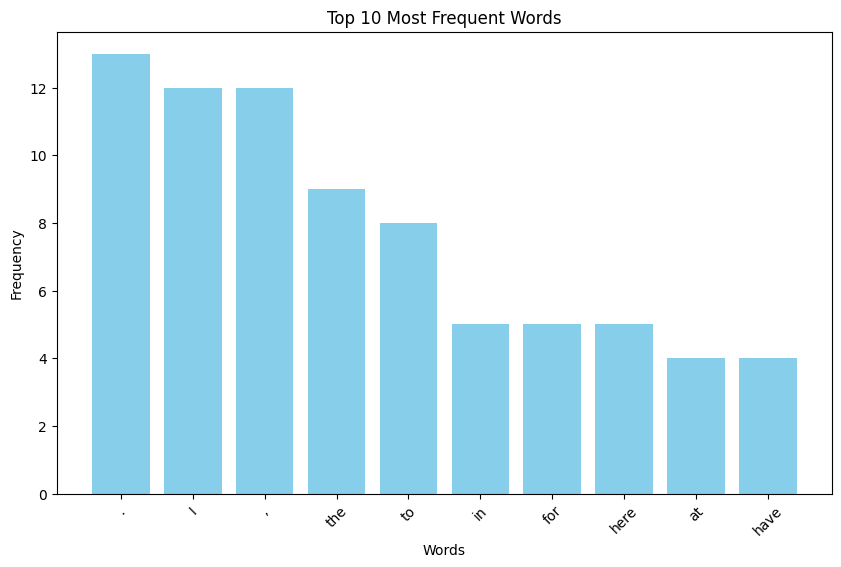

In [ ]:
import heapq
import matplotlib.pyplot as plt

freq_words = heapq.nlargest(10, word2count, key=word2count.get)

print(f"Top 10 frequent words: {freq_words}")

top_words = sorted(word2count.items(), key=lambda x: x[1], reverse=True)[:10]
words, counts = zip(*top_words)

plt.figure(figsize=(10, 6))
plt.bar(words, counts, color='skyblue')
plt.xticks(rotation=45)
plt.title('Top 10 Most Frequent Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

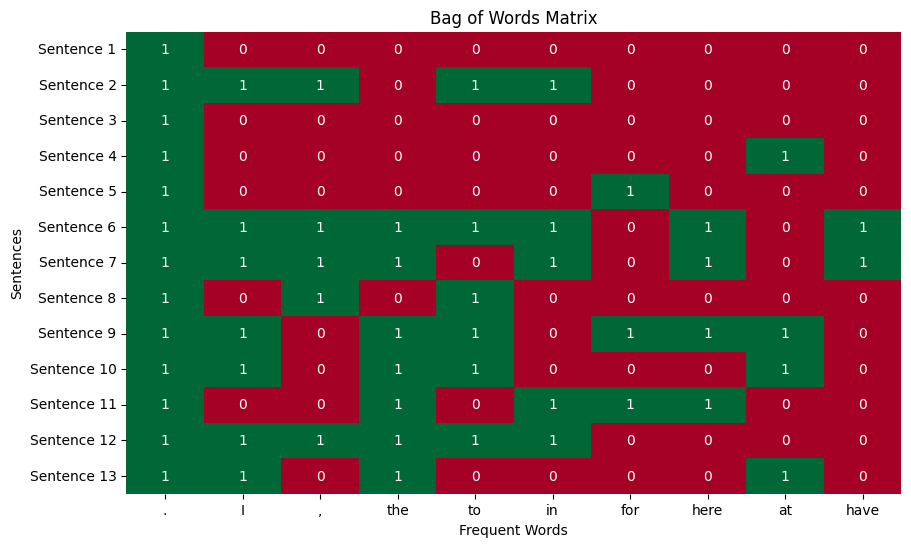

In [ ]:
import numpy as np
import seaborn as sns

X = []

for data in dataset:
    vector = []
    for word in freq_words:
        if word in nltk.word_tokenize(data):
            vector.append(1)
        else:
            vector.append(0)
    X.append(vector)

X = np.asarray(X)

plt.figure(figsize=(10, 6))
sns.heatmap(X, cmap='RdYlGn', cbar=False, annot=True, fmt="d", xticklabels=freq_words, yticklabels=[f"Sentence {i+1}" for i in range(len(dataset))])

plt.title('Bag of Words Matrix')
plt.xlabel('Frequent Words')
plt.ylabel('Sentences')
plt.show()

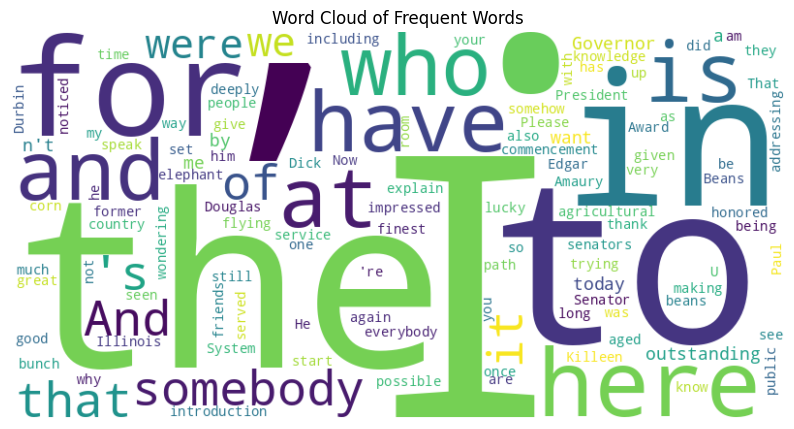

In [ ]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word2count)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Frequent Words")
plt.show()

# TF-IDF (Term Frequency-Inverse Document Frequency)
* A **statistical method used in natural language processing** and information retrieval to **evaluate how important a word is to a document in relation to a larger collection of documents**.
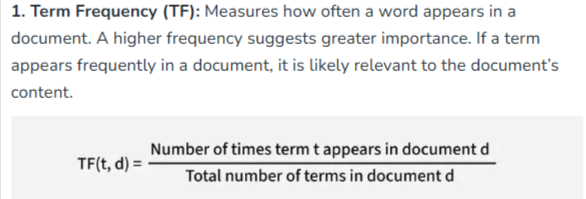

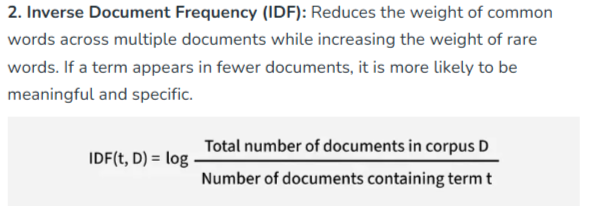


This balance allows TF-IDF to **highlight terms that are both frequent within a specific document and distinctive across the text document**, making it a useful tool for tasks like search ranking, text classification and keyword extraction.

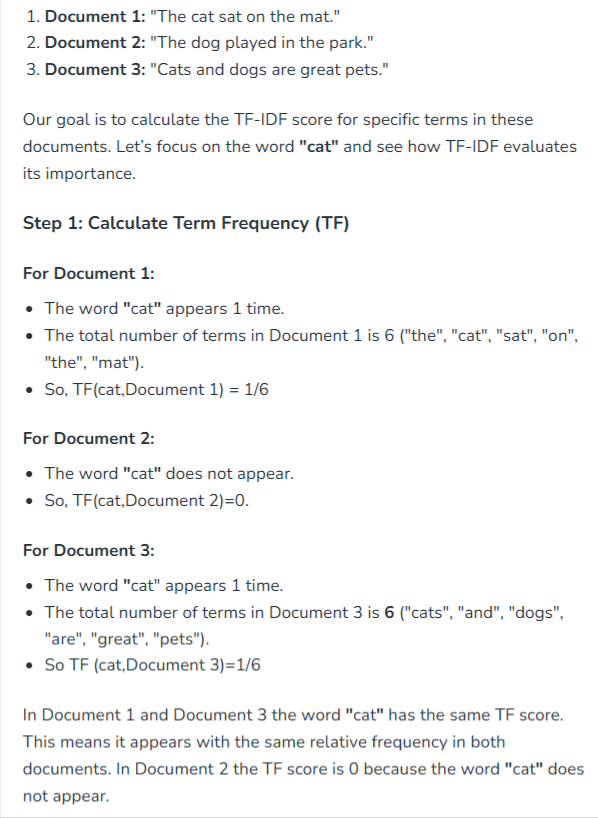

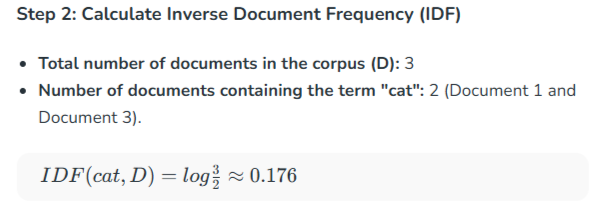

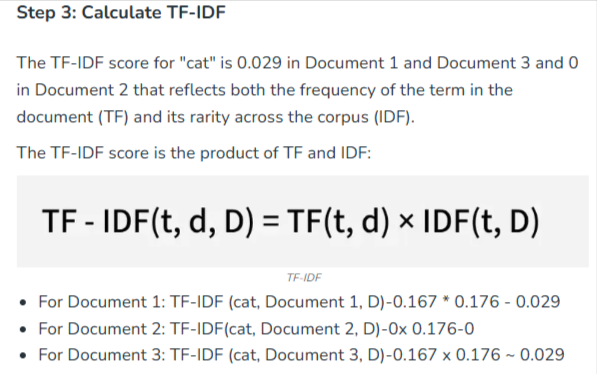

# Co-occurence matrix in NLP
* A mathematical representation that **captures the frequency with which pairs of words appear together** within a **specified context**, such as a sentence, paragraph, or document.

## How Window Size Works
* The window size **defines the boundary for gathering context words**, both **before and after the target word**.
  * Example: If the sentence is "***The quick brown fox jumps over the lazy dog***," and the target word is "***fox.***"
  * ***Window Size = 1***: The context words are $\mathbf{1}$ word to the left and $\mathbf{1}$ word to the right: (***brown, jumps***).
  * ***Window Size = 2***: The context words are $\mathbf{2}$ words to the left and $\mathbf{2}$ words to the right: (***quick, brown, jumps, over***).

## 📏 Impact of Window Size

| Window Size | Context Captured | Information Emphasis |
| :--- | :--- | :--- |
| **Small Window (e.g., 2–5)** | Immediate neighbors. | Captures **syntactic** (grammatical) relationships and functional similarity. Words that can be substituted for one another in a sentence (e.g., *tall* and *big*). |
| **Large Window (e.g., 5–10)** | Broader document context. | Captures **semantic** (meaning) relationships and topical similarity. Words that appear in the same general topic (e.g., *dog* and *leash*). |

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import defaultdict, Counter
import numpy as np
import pandas as pd

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')

# Sample text
text = """Apple is looking at buying U.K. startup for $1 billion.
          The deal is expected to close by January 2022. Apple is very optimistic about the acquisition."""

# Preprocess the text
stop_words = set(stopwords.words('english'))
words = word_tokenize(text.lower())
words = [word for word in words if word.isalnum() and word not in stop_words]

# Define the window size for co-occurrence
window_size = 2

# Create a list of co-occurring word pairs
co_occurrences = defaultdict(Counter)
for i, word in enumerate(words):
    for j in range(max(0, i - window_size), min(len(words), i + window_size + 1)):
        if i != j:
            co_occurrences[word][words[j]] += 1

# Create a list of unique words
unique_words = list(set(words))

# Initialize the co-occurrence matrix
co_matrix = np.zeros((len(unique_words), len(unique_words)), dtype=int)

# Populate the co-occurrence matrix
word_index = {word: idx for idx, word in enumerate(unique_words)}
for word, neighbors in co_occurrences.items():
    for neighbor, count in neighbors.items():
        co_matrix[word_index[word]][word_index[neighbor]] = count

# Create a DataFrame for better readability
co_matrix_df = pd.DataFrame(co_matrix, index=unique_words, columns=unique_words)

# Display the co-occurrence matrix
co_matrix_df

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,apple,startup,optimistic,acquisition,deal,1,close,expected,looking,billion,january,buying
apple,0,0,1,1,0,0,1,0,1,0,1,1
startup,0,0,0,0,0,1,0,0,1,1,0,1
optimistic,1,0,0,1,0,0,0,0,0,0,1,0
acquisition,1,0,1,0,0,0,0,0,0,0,0,0
deal,0,0,0,0,0,1,1,1,0,1,0,0
1,0,1,0,0,1,0,0,0,0,1,0,1
close,1,0,0,0,1,0,0,1,0,0,1,0
expected,0,0,0,0,1,0,1,0,0,1,1,0
looking,1,1,0,0,0,0,0,0,0,0,0,1
billion,0,1,0,0,1,1,0,1,0,0,0,0


# Word2Vec
### 1. CBOW (Continuous Bag of Words)
* Predicts the current word given context words within a specific window.
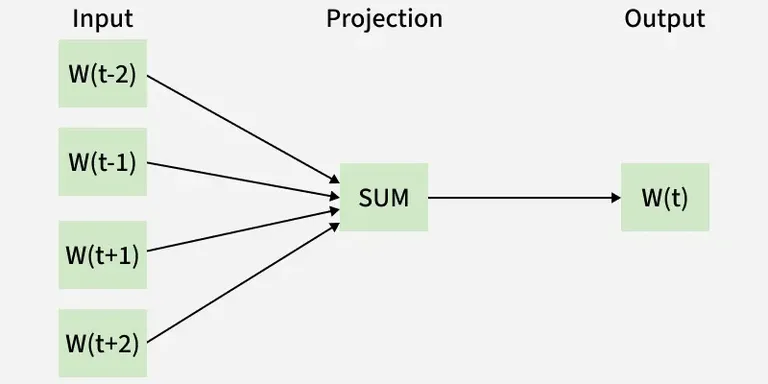

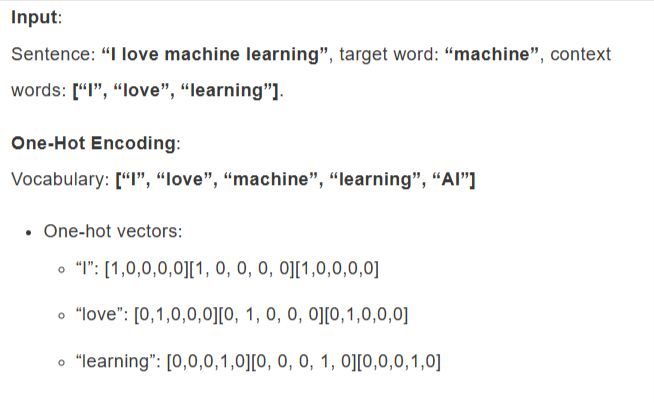

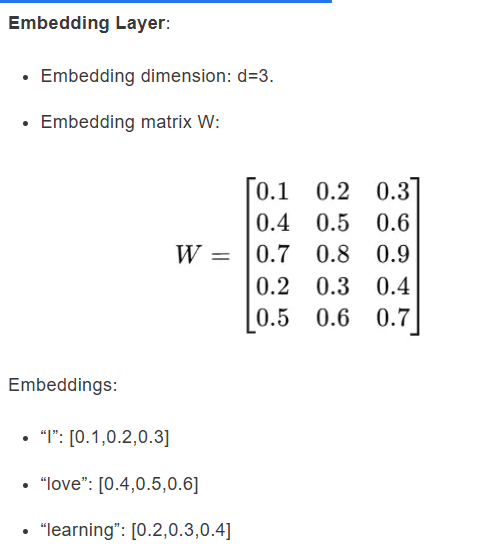

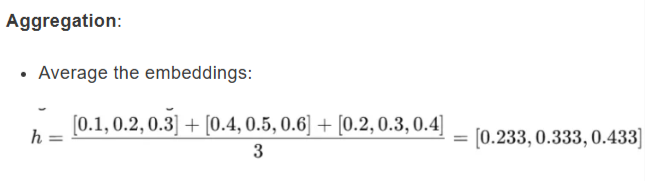

# SKIP GRAM
* Predicts the surrounding context words within specific window given current word.
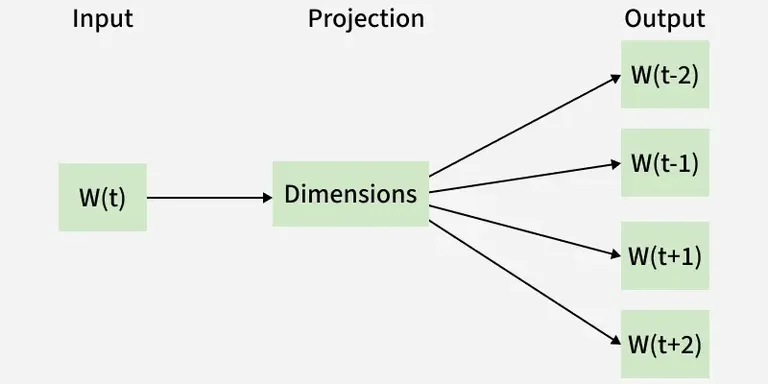

In [ ]:
sentence = "the quick brown fox jumps over the lazy dog"
words = sentence.split()
words


['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']

In [ ]:
vocab = list(set(words))
word_to_id = {w:i for i,w in enumerate(vocab)}
id_to_word = {i:w for w,i in word_to_id.items()}
vocab


['over', 'dog', 'jumps', 'quick', 'lazy', 'the', 'fox', 'brown']

In [ ]:
#CBOW pairs (context → target)
window = 2
cbow_pairs = []

for i, word in enumerate(words):
    target = word
    context = []
    for j in range(i-window, i+window+1):
        if j != i and 0 <= j < len(words):
            context.append(words[j])
    cbow_pairs.append((context, target))

cbow_pairs


[(['quick', 'brown'], 'the'),
 (['the', 'brown', 'fox'], 'quick'),
 (['the', 'quick', 'fox', 'jumps'], 'brown'),
 (['quick', 'brown', 'jumps', 'over'], 'fox'),
 (['brown', 'fox', 'over', 'the'], 'jumps'),
 (['fox', 'jumps', 'the', 'lazy'], 'over'),
 (['jumps', 'over', 'lazy', 'dog'], 'the'),
 (['over', 'the', 'dog'], 'lazy'),
 (['the', 'lazy'], 'dog')]

In [ ]:
#Train a Skip-Gram Model
#Skip-Gram = predict context words from target word
skipgram_pairs = []

for i, word in enumerate(words):
    target = word
    for j in range(i-window, i+window+1):
        if j != i and 0 <= j < len(words):
            skipgram_pairs.append((target, words[j]))

skipgram_pairs


[('the', 'quick'),
 ('the', 'brown'),
 ('quick', 'the'),
 ('quick', 'brown'),
 ('quick', 'fox'),
 ('brown', 'the'),
 ('brown', 'quick'),
 ('brown', 'fox'),
 ('brown', 'jumps'),
 ('fox', 'quick'),
 ('fox', 'brown'),
 ('fox', 'jumps'),
 ('fox', 'over'),
 ('jumps', 'brown'),
 ('jumps', 'fox'),
 ('jumps', 'over'),
 ('jumps', 'the'),
 ('over', 'fox'),
 ('over', 'jumps'),
 ('over', 'the'),
 ('over', 'lazy'),
 ('the', 'jumps'),
 ('the', 'over'),
 ('the', 'lazy'),
 ('the', 'dog'),
 ('lazy', 'over'),
 ('lazy', 'the'),
 ('lazy', 'dog'),
 ('dog', 'the'),
 ('dog', 'lazy')]

# Pretrained Word-Embedding
* Are ***representations of words that are learned from large corpora*** and are made available for reuse in various Natural Language Processing (NLP) tasks.


## Glove Word Embedding
* **Unsupervised learning algorithm** designed to generate dense vector representations also known as embeddings.
* Capture **semantic relationships between words** by **analyzing their co-occurrence patterns** in a large text corpus.

###Combines the strengths of two major approaches:

1. **Latent Semantic Analysis (LSA)** which uses global statistical information.Similar to  ***TF-IDF***
2. **Context-based models** like Word2Vec which focuses on local word context.

## Words that appear in similar contexts have similar meanings.
***Word2Vec (which learns using prediction), GloVe learns using word co-occurrence counts.***

It builds a **HUGE** matrix:

| word | king | queen | apple | … |
| :--- | :--- | :--- | :--- | :--- |
| **king** | 0 | 52 | 0 | … |
| **queen** | 52 | 0 | 0 | … |
| **apple** | 0 | 0 | 200 | … |
| **…** | … | … | … | … |

Then it factorizes this matrix into dense vectors

This leads to famous relationships:

***king – man + woman ≈ queen***

***paris – france + italy ≈ rome***


In [ ]:
#####################################

# Self-attention
* Is similar to the **human behavioral concept** in that they both **involve focusing on relevant elements** within a **larger context** to accurately process information.
* Captures **long range dependencies** by **calculating attention between all words in the sequence** and helping the model to **look at the entire sequence at once**.


# Steps in self-attention
1. Embedding the input sequence
2. Generate vectors for the attention function
  * generate three key vectors for each token: **query (Q), key (K) and value (V)**

3. Compute the attention scores
  * scaled **dot product** attention scores between the **query vectors and key vectors**.
  * attention weights represent **how much focus (or attention)** a **specific token should give to other tokens in a sequence**.

  4. Transform the attention scores into probabilities

### **Input sentence**

***“I love NLP”***
1.

  | Token | Embedding |
  | ----- | --------- |
  | I     | 1.0       |
  | love  | 2.0       |
  | NLP   | 3.0       |

  X = [1.0, 2.0, 3.0]

2.
**Generate Q, K, V vectors**

In real models, Q, K, V = X × W matrices.

W_Q = 2
W_K = 2
W_V = 1


Q = X * W_Q = [1 * 2, 2 * 2, 3*2] = [2, 4, 6]

K = X * W_K = [1 * 2, 2 * 2, 3 * 2] = [2, 4, 6]

V = X * W_V = [1 * 1, 2 * 1, 3 * 1] = [1, 2, 3]




3. **Compute Attention Scores: dot(Qᵢ, Kⱼ)**

We compute all pairwise dot products:

For token “I” (Q = 2):

score(I→I) = 2×2 = 4

score(I→love) = 2×4 = 8

score(I→NLP) = 2×6 = 12

For token “love” (Q = 4):

score(love→I) = 4×2 = 8

score(love→love) = 4×4 = 16

score(love→NLP) = 4×6 = 24

For token “NLP” (Q = 6):

score(NLP→I) = 6×2 = 12

score(NLP→love) = 6×4 = 24

score(NLP→NLP) = 6×6 = 36

So the attention score matrix is:

[[ 4,  8, 12],
 [ 8, 16, 24],
 [12, 24, 36]]

4. **Scale the scores**

Transformers divide by √d

Here d = 1, so √1 = 1 → scores stay same.

scaled_scores = scores

5. **Apply Softmax (convert scores to probabilities)**

We apply softmax row-wise (each query looks at all keys).

For token “I”:

Scores: [4, 8, 12]

Compute softmax:

exp(4)  = 54.60

exp(8)  = 2981.01

exp(12) = 162754.79

sum = 165790.40


Probabilities:

I→I     = 54.6 / 165790.4 = 0.000329

I→love  = 2981 / 165790.4 = 0.01797

I→NLP   = 162755 / 165790.4 = 0.9817


So "I" mostly attends to NLP (because of toy weights).

For “love”:

Scores: [8, 16, 24]

Same process → results:

[0.000329, 0.01797, 0.9817]

For “NLP”:

Scores: [12, 24, 36]

Softmax:

[0.000329, 0.01797, 0.9817]


So every token attends mostly to “NLP” (in this toy example).

6. **Compute the weighted sum of Value (V)**

We multiply each row of attention weights with V:

V = [1, 2, 3]

For “I”:
output_I = (0.000329)*1 + (0.01797)*2 + (0.9817)*3
         = 2.964

For “love”:

Same:

output_love = 2.964

For “NLP”:

Same:

output_NLP = 2.964

⭐ Final Self-Attention Output
output = [2.964, 2.964, 2.964]


                ┌──────────────────────────┐
                │     Input Sequence       │
                │   ["I", "love", "NLP"]   │
                └────────────┬─────────────┘
                             │
                             ▼
                ┌──────────────────────────┐
                │   1. Embedding Layer     │
                │  I → 1.0                 │
                │  love → 2.0              │
                │  NLP → 3.0               │
                └────────────┬─────────────┘
                             │  X
                             ▼
       ┌────────────────────────────────────────────────────┐
       │ 2. Linear Projections → Create Q, K, V vectors     │
       │                                                    │
       │     Q = X · W_Q     K = X · W_K      V = X · W_V   │
       │                                                    │
       │    ┌─────────┐   ┌─────────┐   ┌─────────┐        │
       │    │   Q     │   │   K     │   │   V     │        │
       │    │ [2,4,6] │   │ [2,4,6] │   │ [1,2,3] │        │
       │    └─────────┘   └─────────┘   └─────────┘        │
       └───────────────┬────────────────────┬──────────────┘
                       │                    │
                       ▼                    ▼
         ┌─────────────────────┐   ┌─────────────────────────┐
         │ 3. Dot Products     │   │ 4. Scale the Scores     │
         │                     │   │ (divide by sqrt(d_k))   │
         │  Q × Kᵀ → scores    │   │                         │
         │                     │   │                         │
         │   [4, 8, 12]        │   │    same values          │
         └───────────┬─────────┘   └─────────────┬──────────┘
                     │                            │
                     ▼                            ▼
           ┌──────────────────────────┐   ┌────────────────────────────┐
           │ 5. Softmax               │   │ 6. Weighted Sum            │
           │ (row-wise)              │   │ (weights × V)              │
           │                          │   │                            │
           │ [0.0003, 0.018, 0.982]   │   │ output token = Σ(weight·V) │
           └────────────┬─────────────┘   └───────────────┬────────────┘
                        │                                 │
                        ▼                                 ▼
                 ┌─────────────────────────────────────────────┐
                 │         Self-Attention Output                │
                 │      [2.964, 2.964, 2.964]                  │
                 └─────────────────────────────────────────────┘


$$\text{Attention}(\mathbf{Q}, \mathbf{K}, \mathbf{V}) = \text{softmax}\left(\frac{\mathbf{QK}^T}{\sqrt{d_k}}\right)\mathbf{V}$$

In [ ]:
##########################

# Multi-Head Attention
* Extends self-attention by **splitting the input into multiple heads**, enabling the model to capture diverse relationships and patterns.

                        ┌──────────────────────────┐
                        │      Input Sequence      │
                        │   ["I", "love", "NLP"]   │
                        └────────────┬─────────────┘
                                     │
                                     ▼
                        ┌──────────────────────────┐
                        │        Embeddings        │
                        │   X = [x1, x2, x3]       │
                        └────────────┬─────────────┘
                                     │
                                     ▼
         ┌─────────────────────────────────────────────────────────────┐
         │                Multi-Head Self Attention                    │
         ├─────────────────────────────────────────────────────────────┤
         │                                                             │
         │   Split the model dimension into multiple heads             │
         │                                                             │
         │      Head 1               Head 2                Head 3      │
         │   ┌───────────┐       ┌───────────┐        ┌───────────┐   │
         │   │ Q1 = X WQ1│       │ Q2 = X WQ2│        │ Q3 = X WQ3│   │
         │   │ K1 = X WK1│       │ K2 = X WK2│        │ K3 = X WK3│   │
         │   │ V1 = X WV1│       │ V2 = X WV2│        │ V3 = X WV3│   │
         │   └─────┬─────┘       └─────┬─────┘        └─────┬─────┘   │
         │         │                  │                     │          │
         │         ▼                  ▼                     ▼          │
         │   ┌──────────────┐   ┌──────────────┐    ┌──────────────┐   │
         │   │ Scaled        │   │ Scaled        │    │ Scaled        │   │
         │   │ Dot-Product   │   │ Dot-Product   │    │ Dot-Product   │   │
         │   │ Attention     │   │ Attention     │    │ Attention     │   │
         │   └──────────────┘   └──────────────┘    └──────────────┘   │
         │         │                  │                     │          │
         │         ▼                  ▼                     ▼          │
         │   ┌──────────────┐   ┌──────────────┐    ┌──────────────┐   │
         │   │ Output of     │   │ Output of     │    │ Output of     │   │
         │   │ Head 1        │   │ Head 2        │    │ Head 3        │   │
         │   └──────────────┘   └──────────────┘    └──────────────┘   │
         │                                                             │
         ├─────────────────────────────────────────────────────────────┤
         │                 Concatenate Head Outputs                    │
         │   ┌──────────────────────────────────────────────────────┐   │
         │   │   [Head1 || Head2 || Head3] → Combined vector (Z)    │   │
         │   └──────────────────────────────────────────────────────┘   │
         │                                                             │
         ├─────────────────────────────────────────────────────────────┤
         │    Final Linear Projection:  Z × W_output → Final Output   │
         └─────────────────────────────────────────────────────────────┘
                                     │
                                     ▼
                        ┌──────────────────────────┐
                        │   Multi-Head Output      │
                        │  (sent to Feed-Forward)  │
                        └──────────────────────────┘
